# CYSE 686 — Federated Learning Project
## Task 1: Clean FedAvg Baseline on MNIST

**Goal:** Train a global CNN on MNIST using Federated Averaging (FedAvg).  
This notebook establishes the clean baseline before any attacks or defenses.

### Setup
- 20 federated clients, IID split
- 20 communication rounds, 1 local epoch per round
- CNN architecture, SGD optimizer
- Metric: Main Task Accuracy (MTA) after every round

In [1]:
import sys
import os
import torch

sys.path.insert(0, os.path.abspath('..'))

# autoreload picks up any .py edits automatically
%load_ext autoreload
%autoreload 2

from src.data       import get_mnist, iid_split, get_client_loaders, get_test_loader
from src.model      import get_model, count_parameters
from src.client     import client_update
from src.server     import run_round
from src.evaluation import evaluate_mta, evaluate_per_class, evaluate_asr   # ← added
from src.utils      import (plot_accuracy, plot_per_class_accuracy,
                            plot_asr, plot_mta_and_asr,                     # ← added
                            save_results, save_model, print_round_summary)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

PyTorch version : 2.7.1+cu118
CUDA available  : False


## 1. Experiment Configuration

All hyperparameters in one place — easy to change for later experiments.

In [ ]:
# ── Federated Learning Setup ───────────────────────────────────
NUM_CLIENTS        = 20      # Total number of federated clients
CLIENT_FRACTION    = 1.0     # Fraction of clients per round (1.0 = all)
NUM_ROUNDS         = 20      # Number of communication rounds

# ── Local Training ──────────────────────────────────────────────
LOCAL_EPOCHS           = 1    # honest clients: 1 local epoch
MALICIOUS_LOCAL_EPOCHS = 3    # ← NEW: malicious clients: 3 local epochs
LOCAL_LR               = 0.01
BATCH_SIZE             = 32

AGGREGATION_METHOD = "krum"

# ── Evaluation ──────────────────────────────────────────────────
TEST_BATCH_SIZE    = 512     # Larger batch for faster inference

# ── Device ──────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# ── Paths ───────────────────────────────────────────────────────
RESULTS_DIR = '../results/'   # capital R — matches your actual folder

# ── Attack Configuration (Task 3 — Multi-source) ───────────────
MALICIOUS_RATIO = 0.2    # 20% of clients → 8 out of 20

# Multi-source label flip map: {source: target}
LABEL_FLIP_MAP  = {
    7: 1,   # sevens  → ones
    9: 4,   # nines   → fours
    3: 8,   # threes  → eights
}

# Select malicious clients (fixed across all rounds)
from src.client import select_malicious_clients

malicious_clients = select_malicious_clients(
    num_total_clients = NUM_CLIENTS,
    malicious_ratio   = MALICIOUS_RATIO,
    seed              = 42
)

NUM_MALICIOUS = len(malicious_clients)
# Print so it's visible in the notebook output
print(f"  Honest epochs   : {LOCAL_EPOCHS}")
print(f"  Malicious epochs: {MALICIOUS_LOCAL_EPOCHS}  ← boosted")

print(f"\n[Attack] Multi-source label-flip map:")
for src, tgt in LABEL_FLIP_MAP.items():
    print(f"  {src} → {tgt}")
print(f"[Attack] Malicious clients: {sorted(malicious_clients)}")

Using device: cpu
[Attack] 4 malicious clients (20% of 20): [0, 3, 7, 8]
  Honest epochs   : 1
  Malicious epochs: 3  ← boosted

[Attack] Multi-source label-flip map:
  7 → 1
  9 → 4
  3 → 8
[Attack] Malicious clients: [0, 3, 7, 8]


## 2. Load and Split Data

In [3]:
# Download MNIST (cached after first run — stored in ../data/)
train_dataset, test_dataset = get_mnist(data_dir='../data')

# IID split across NUM_CLIENTS clients
client_datasets = iid_split(train_dataset, num_clients=NUM_CLIENTS)

# Create DataLoaders for training and evaluation
client_loaders = get_client_loaders(client_datasets, batch_size=BATCH_SIZE)
test_loader    = get_test_loader(test_dataset, batch_size=TEST_BATCH_SIZE)

# Verify split sizes
sizes = [len(dl.dataset) for dl in client_loaders]
print(f"\nClient dataset sizes: {sizes}")
print(f"Total samples distributed: {sum(sizes)}")

[Data] Train size: 60000, Test size: 10000
[Data] IID split → 20 clients, ~3000 samples each

Client dataset sizes: [3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000]
Total samples distributed: 60000


## 3. Initialize Global Model

In [4]:
# Initialize a fresh global model with random weights
global_model = get_model()
global_model.to(DEVICE)

# Print architecture and parameter count
print(global_model)
count_parameters(global_model)

# Evaluate BEFORE any training (expect ~10% = random chance)
init_mta, init_loss = evaluate_mta(global_model, test_loader, DEVICE)
print(f"\nRandom init MTA: {init_mta*100:.2f}%  (expect ~10% for random model)")

MnistCNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
[Model] Trainable parameters: 582,026

Random init MTA: 7.82%  (expect ~10% for random model)


## 4. FedAvg Training Loop

Run for `NUM_ROUNDS` communication rounds. After each round the global model is evaluated on the full MNIST test set and MTA is recorded.

In [5]:
print("=" * 65)
print(" FedAvg — Boosted Multi-Source Label-Flipping Attack")
mappings_str = ", ".join(f"{s}→{t}" for s, t in LABEL_FLIP_MAP.items())
print(f" Attack mappings  : {mappings_str}")
print(f" Malicious ({MALICIOUS_RATIO*100:.0f}%)  : {sorted(malicious_clients)}")
print(f" Honest epochs    : {LOCAL_EPOCHS}")
print(f" Malicious epochs : {MALICIOUS_LOCAL_EPOCHS}  ← boosted")
print("=" * 65)

mta_history         = []
asr_history         = []
per_mapping_history = []
loss_history        = []
best_mta            = 0.0

for round_num in range(1, NUM_ROUNDS + 1):

    global_model, round_losses = run_round(
        round_num              = round_num,
        global_model           = global_model,
        client_loaders         = client_loaders,
        client_update_fn       = client_update,
        local_epochs           = LOCAL_EPOCHS,
        lr                     = LOCAL_LR,
        device                 = DEVICE,
        client_fraction        = CLIENT_FRACTION,
        malicious_clients      = malicious_clients,
        label_flip_map         = LABEL_FLIP_MAP,
        malicious_local_epochs = MALICIOUS_LOCAL_EPOCHS,  # ← NEW
        verbose                = False
    )

    # ── Evaluate MTA ──────────────────────────────────────────────
    mta, test_loss = evaluate_mta(global_model, test_loader, DEVICE)
    mta_history.append(mta)
    loss_history.append(test_loss)

    # ── Evaluate ASR ──────────────────────────────────────────────
    overall_asr, per_mapping = evaluate_asr(
        model          = global_model,
        test_loader    = test_loader,
        label_flip_map = LABEL_FLIP_MAP,
        device         = DEVICE
    )
    asr_history.append(overall_asr)
    per_mapping_history.append(per_mapping)

    # ── Print round summary ───────────────────────────────────────
    is_best = mta > best_mta
    star    = " ★" if is_best else "  "
    print(f"  Round {round_num:3d}{star} | "
          f"MTA: {mta*100:6.2f}% | "
          f"ASR: {overall_asr*100:6.2f}% | "
          f"Loss: {test_loss:.4f}")

    # Per-mapping breakdown every 5 rounds
    if round_num % 5 == 0:
        print(f"    ↳ Per-mapping ASR:")
        for (src, tgt), info in per_mapping.items():
            print(f"       {src}→{tgt} : {info['asr']*100:.1f}%  "
                  f"({info['flipped']}/{info['total']} samples)")

    if is_best:
        best_mta = mta

print("=" * 65)
print(f" Done!  Best MTA: {best_mta*100:.2f}%  |  "
      f"Final ASR: {asr_history[-1]*100:.2f}%")
print("=" * 65)

 FedAvg — Boosted Multi-Source Label-Flipping Attack
 Attack mappings  : 7→1, 9→4, 3→8
 Malicious (20%)  : [0, 3, 7, 8]
 Honest epochs    : 1
 Malicious epochs : 3  ← boosted
  [Attack] Client 0 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  [Attack] Client 3 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  [Attack] Client 7 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  [Attack] Client 8 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  Round   1 ★ | MTA:  88.06% | ASR:  20.35% | Loss: 0.3187
  [Attack] Client 0 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  [Attack] Client 3 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  [Attack] Client 7 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  [Attack] Client 8 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  Round   2 ★ | MTA:  91.97% | ASR:  13.65% | Loss: 0.2299
  [Attack] Client 0 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  [Attack] Client 3 is MALICIOUS — flipping labels: 7→1, 9→4, 3→8
  [Attack] Client 7 is MALICIOUS — flipping lab

## 5. Plot Accuracy Over Rounds

[Utils] Figure saved to: ../results/multisource_enhanced_mta.png


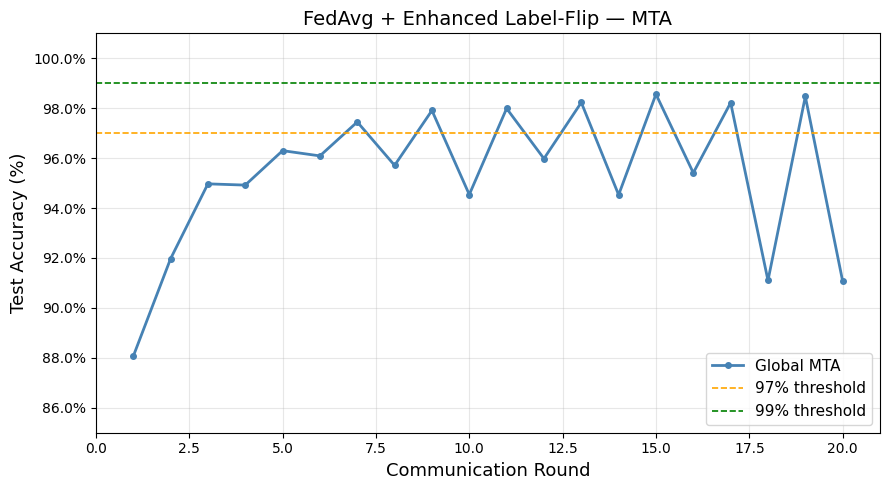

[Utils] Figure saved to: ../results/multisource_enhanced_asr.png


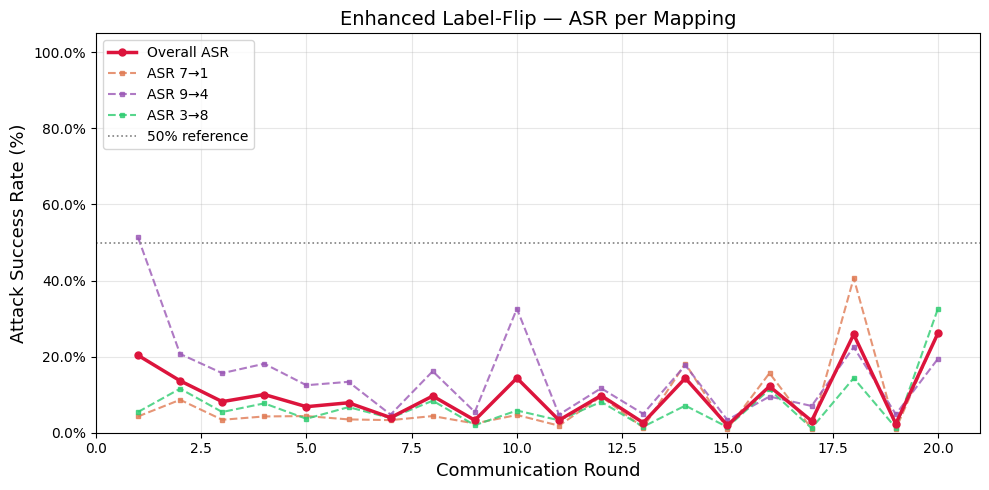

[Utils] Figure saved to: ../results/multisource_enhanced_mta_vs_asr.png


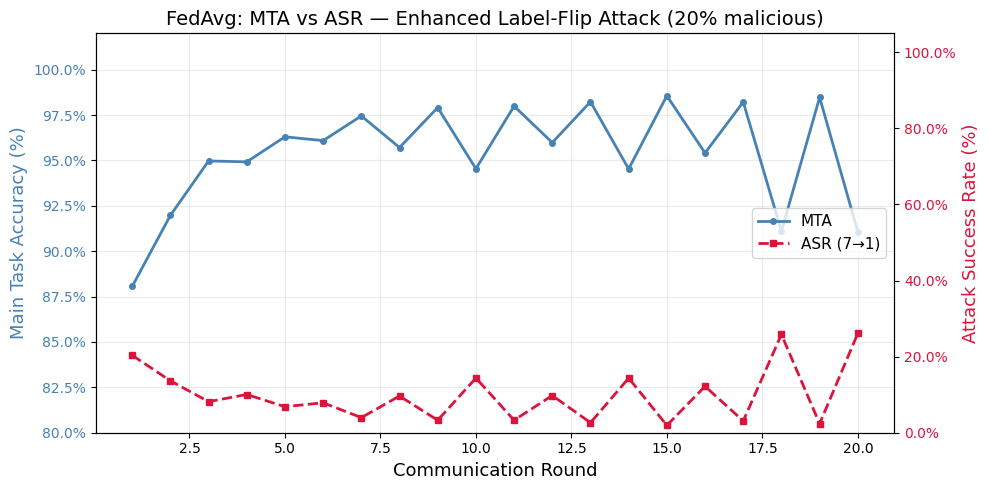

In [6]:
# ── Plot 1: MTA ───────────────────────────────────────────────────
plot_accuracy(
    accuracies = mta_history,
    title      = f"FedAvg + Enhanced Label-Flip — MTA",
    save_path  = f"{RESULTS_DIR}multisource_enhanced_mta.png"
)

# ── Plot 2: ASR (overall + per-mapping breakdown) ─────────────────
plot_asr(
    asr_list            = asr_history,
    label_flip_map      = LABEL_FLIP_MAP,
    per_mapping_history = per_mapping_history,
    title               = "Enhanced Label-Flip — ASR per Mapping",
    save_path           = f"{RESULTS_DIR}multisource_enhanced_asr.png"
)

# ── Plot 3: MTA vs ASR combined ───────────────────────────────────
plot_mta_and_asr(
    mta_list  = mta_history,
    asr_list  = asr_history,
    title     = f"FedAvg: MTA vs ASR — Enhanced Label-Flip Attack ({MALICIOUS_RATIO*100:.0f}% malicious)",
    save_path = f"{RESULTS_DIR}multisource_enhanced_mta_vs_asr.png"
)

## 6. Per-Class Accuracy Breakdown

Per-class accuracy (final global model):
  Digit 0: 99.69%
  Digit 1: 99.91%
  Digit 2: 99.52%
  Digit 3: 65.25%
  Digit 4: 99.90%
  Digit 5: 99.55%
  Digit 6: 98.96%
  Digit 7: 71.50%
  Digit 8: 99.59%
  Digit 9: 78.10%


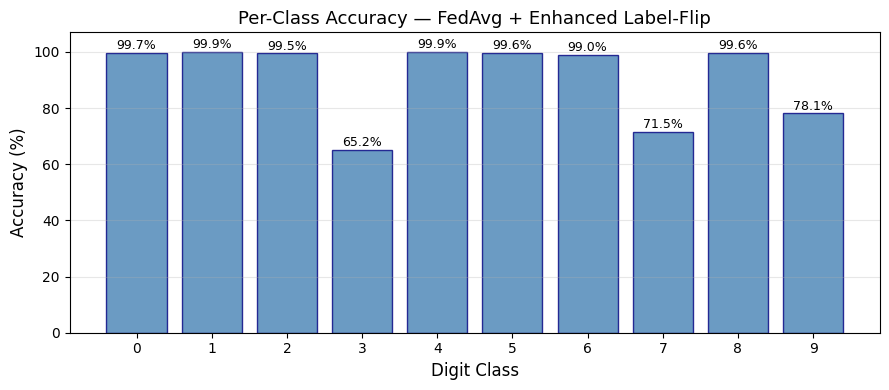

In [7]:
# Check accuracy for each digit class 0–9
per_class = evaluate_per_class(global_model, test_loader, DEVICE)

print("Per-class accuracy (final global model):")
for cls, acc in per_class.items():
    print(f"  Digit {cls}: {acc*100:.2f}%")

plot_per_class_accuracy(
    per_class_acc = per_class,
    title         = "Per-Class Accuracy — FedAvg + Enhanced Label-Flip",
    save_path     = f"{RESULTS_DIR}enhanced_per_class.png"
)

## 7. Save Results & Model

In [ ]:
# Serialize per_mapping_history for JSON
asr_per_mapping_serializable = []
for round_data in per_mapping_history:
    round_dict = {}
    for (src, tgt), info in round_data.items():
        round_dict[f"{src}→{tgt}"] = {
            "asr"    : info["asr"],
            "flipped": info["flipped"],
            "total"  : info["total"],
        }
    asr_per_mapping_serializable.append(round_dict)

results = {
    "experiment"              : "task4_boosted_multisource_label_flip",
    "num_clients"             : NUM_CLIENTS,
    "num_rounds"              : NUM_ROUNDS,
    "client_fraction"         : CLIENT_FRACTION,
    # ── attack config ──────────────────────────────────────────
    "malicious_ratio"         : MALICIOUS_RATIO,
    "malicious_clients"       : sorted(malicious_clients),
    "label_flip_map"          : {str(k): v for k, v in LABEL_FLIP_MAP.items()},
    "local_epochs_honest"     : LOCAL_EPOCHS,
    "local_epochs_malicious"  : MALICIOUS_LOCAL_EPOCHS,   # ← NEW
    "learning_rate"           : LOCAL_LR,
    "batch_size"              : BATCH_SIZE,
    # ── MTA ────────────────────────────────────────────────────
    "mta_history"             : mta_history,
    "final_mta"               : mta_history[-1],
    "best_mta"                : best_mta,
    # ── ASR ────────────────────────────────────────────────────
    "asr_history"             : asr_history,
    "final_asr"               : asr_history[-1],
    "best_asr"                : max(asr_history),
    "asr_per_mapping"         : asr_per_mapping_serializable,
    # ── loss ───────────────────────────────────────────────────
    "loss_history"            : loss_history,
}

save_results(results, path=f"{RESULTS_DIR}defense results/task4_boosted_results.json")
save_model(global_model,  path=f"{RESULTS_DIR}defense results/task4_boosted_model.pt")

print("\n=== Task 4 — Boosted Multi-Source Attack Final Summary ===")
print(f"  Attack       : Boosted Multi-Source Label-Flipping")
print(f"  Mappings     : {mappings_str}")
print(f"  Malicious    : {sorted(malicious_clients)}")
print(f"  Honest E     : {LOCAL_EPOCHS} epoch")
print(f"  Malicious E  : {MALICIOUS_LOCAL_EPOCHS} epochs  ← boosted")
print(f"  Final MTA    : {results['final_mta']*100:.2f}%")
print(f"  Best MTA     : {results['best_mta']*100:.2f}%")
print(f"  Final ASR    : {results['final_asr']*100:.2f}%")
print(f"  Best ASR     : {results['best_asr']*100:.2f}%")
print(f"\n  Per-mapping ASR (final round):")
for (src, tgt), info in per_mapping.items():
    print(f"    {src}→{tgt} : {info['asr']*100:.1f}%  "
          f"({info['flipped']}/{info['total']} samples)")

[Utils] Results saved to: ../results/task4_boosted_results.json
[Utils] Model saved to: ../results/task4_boosted_model.pt

=== Task 4 — Boosted Multi-Source Attack Final Summary ===
  Attack       : Boosted Multi-Source Label-Flipping
  Mappings     : 7→1, 9→4, 3→8
  Malicious    : [0, 3, 7, 8]
  Honest E     : 1 epoch
  Malicious E  : 3 epochs  ← boosted
  Final MTA    : 91.07%
  Best MTA     : 98.56%
  Final ASR    : 26.12%
  Best ASR     : 26.12%

  Per-mapping ASR (final round):
    7→1 : 26.4%  (271/1028 samples)
    9→4 : 19.4%  (196/1009 samples)
    3→8 : 32.6%  (329/1010 samples)
